# Visual laboratory: matrices as transformations

We inspect three equivalent or connected views: basis vectors moving into matrix columns, columns composing $A\vec x$, and rank determining the dimension of the reachable image.

## Columns are transformed basis vectors

For

$$
A=\begin{bmatrix}2&-1\\1&2\end{bmatrix},
$$

the first column is $A\vec e_1$ and the second is $A\vec e_2$.

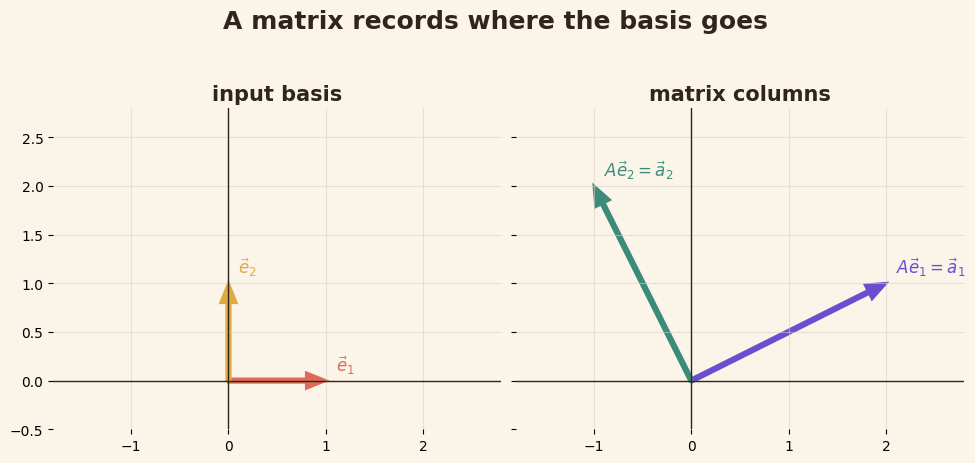

In [1]:
import numpy as np
import matplotlib.pyplot as plt

paper='#fbf4e8'; ink='#30241d'; purple='#6c4ccf'; coral='#dd6b55'; teal='#3d8c7a'; gold='#dfaa3f'; grid='#d9cfc1'
A=np.array([[2.,-1.],[1.,2.]])
a1=A[:,0]; a2=A[:,1]

def arrow(ax, origin, vec, color, label, width=.035):
    ax.arrow(*origin,*vec,length_includes_head=True,head_width=.16,head_length=.2,linewidth=2,width=width,color=color)
    p=np.asarray(origin)+np.asarray(vec); ax.text(p[0]+.1,p[1]+.1,label,color=color,fontsize=12,weight='bold')

fig, axes=plt.subplots(1,2,figsize=(10,5),facecolor=paper,sharex=True,sharey=True)
for ax in axes:
    ax.set_facecolor(paper); ax.axhline(0,color=ink,lw=1); ax.axvline(0,color=ink,lw=1); ax.grid(color=grid,alpha=.55); ax.set_aspect('equal')
    ax.set_xlim(-1.8,2.8); ax.set_ylim(-.5,2.8)
    for s in ax.spines.values(): s.set_visible(False)
arrow(axes[0],(0,0),(1,0),coral,r'$\vec e_1$'); arrow(axes[0],(0,0),(0,1),gold,r'$\vec e_2$')
axes[0].set_title('input basis',color=ink,fontsize=15,weight='bold')
arrow(axes[1],(0,0),a1,purple,r'$A\vec e_1=\vec a_1$'); arrow(axes[1],(0,0),a2,teal,r'$A\vec e_2=\vec a_2$')
axes[1].set_title('matrix columns',color=ink,fontsize=15,weight='bold')
fig.suptitle('A matrix records where the basis goes',color=ink,fontsize=18,weight='bold')
fig.tight_layout(); plt.show()

## Input coordinates weight the columns

For $\vec x=(3,4)$,

$$
A\vec x=3\vec a_1+4\vec a_2=(2,11).
$$

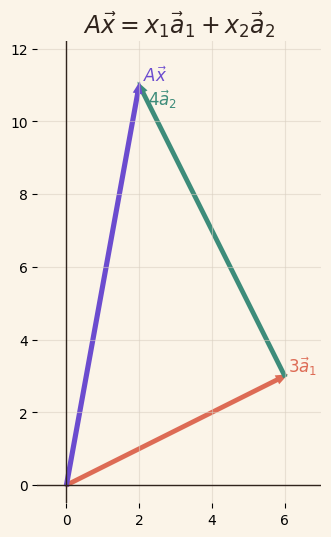

In [2]:
x=np.array([3.,4.]); p1=x[0]*a1; p2=x[1]*a2; y=A@x
fig, ax=plt.subplots(figsize=(7,6),facecolor=paper); ax.set_facecolor(paper)
arrow(ax,(0,0),p1,coral,r'$3\vec a_1$',width=.055)
arrow(ax,p1,p2,teal,'',width=.055)
ax.text(2.25,10.45,r'$4\vec a_2$',color=teal,fontsize=12,weight='bold')
arrow(ax,(0,0),y,purple,r'$A\vec x$',width=.065)
ax.axhline(0,color=ink,lw=1); ax.axvline(0,color=ink,lw=1); ax.grid(color=grid,alpha=.55)
ax.set_xlim(-.8,7); ax.set_ylim(-.5,12.2); ax.set_aspect('equal')
ax.set_title(r'$A\vec x=x_1\vec a_1+x_2\vec a_2$',color=ink,fontsize=17,weight='bold')
for s in ax.spines.values(): s.set_visible(False)
plt.show()

## Rank controls the dimension of the image

A full-rank map sends the coordinate grid to another two-dimensional grid. A rank-one map collapses the entire plane onto a line.

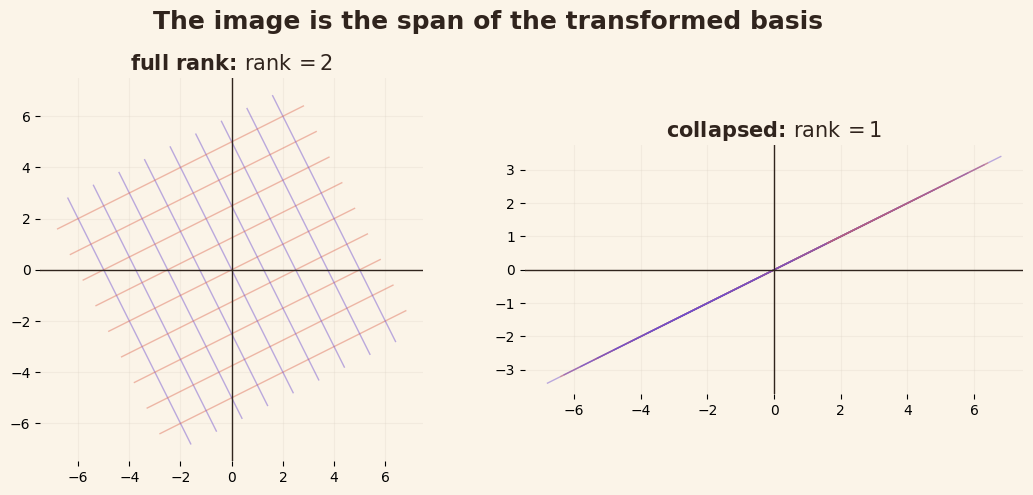

In [3]:
singular=np.array([[1.,2.],[.5,1.]])
def draw_transformed_grid(ax,M,title):
    vals=np.linspace(-2,2,9)
    line=np.linspace(-2.4,2.4,120)
    for c in vals:
        vertical=M@np.vstack([np.full_like(line,c),line])
        horizontal=M@np.vstack([line,np.full_like(line,c)])
        ax.plot(vertical[0],vertical[1],color=purple,alpha=.45,lw=1)
        ax.plot(horizontal[0],horizontal[1],color=coral,alpha=.45,lw=1)
    ax.axhline(0,color=ink,lw=1); ax.axvline(0,color=ink,lw=1); ax.set_aspect('equal'); ax.grid(color=grid,alpha=.25)
    ax.set_title(title,color=ink,fontsize=15,weight='bold')
    for s in ax.spines.values(): s.set_visible(False)
fig,axes=plt.subplots(1,2,figsize=(11,5),facecolor=paper)
for ax in axes: ax.set_facecolor(paper)
draw_transformed_grid(axes[0],A,r'full rank: $\operatorname{rank}=2$')
draw_transformed_grid(axes[1],singular,r'collapsed: $\operatorname{rank}=1$')
fig.suptitle('The image is the span of the transformed basis',color=ink,fontsize=18,weight='bold')
fig.tight_layout(); plt.show()